In [ ]:
import pickle
import cv2
import numpy as np
from matplotlib import pyplot as plt

with open('../../ETL/data/pickles/processed.pkl', 'rb') as file:
	data = pickle.load(file)
with open('../../ETL/data/pickles/patches.pkl', 'rb') as file:
	patches = pickle.load(file)

In [2]:
data.keys()

dict_keys(['set12', 'bsd68', 'div2k'])

In [49]:
import numpy as np

def estimate_speckle_var_from_patches(
    images,
    patch_size=16,
    target_mean=0.5,
    tol=0.05,
    max_patches_per_image=200,
    seed=0
):
    rng = np.random.default_rng(seed)
    speckle_vars = []

    for img in images:
        H, W = img.shape
        if H < patch_size or W < patch_size:
            continue

        for _ in range(max_patches_per_image):
            i = rng.integers(0, H - patch_size + 1)
            j = rng.integers(0, W - patch_size + 1)

            patch = img[i:i+patch_size, j:j+patch_size]
            m = patch.mean()

            # condition mean ≈ 0.5
            if abs(m - target_mean) <= tol:
                vY = patch.var()
                # Var(N) ≈ Var(Y) / m^2
                vN = vY / (m**2 + 1e-12)
                speckle_vars.append(vN)

    if len(speckle_vars) == 0:
        raise RuntimeError("Aucun patch ne respecte la condition sur le mean.")

    return float(np.mean(speckle_vars)), len(speckle_vars)

# exemple d’usage
images_noisy = data['bsd68']['noisy']  # liste d’images float32 [0,1]
vN_est, n_patches = estimate_speckle_var_from_patches(
    images_noisy,
    patch_size=32,
    target_mean=0.5,
    tol=0.05
)

print("Var(N) estimée =", vN_est, "à partir de", n_patches, "patches")


Var(N) estimée = 0.30715975165367126 à partir de 2799 patches


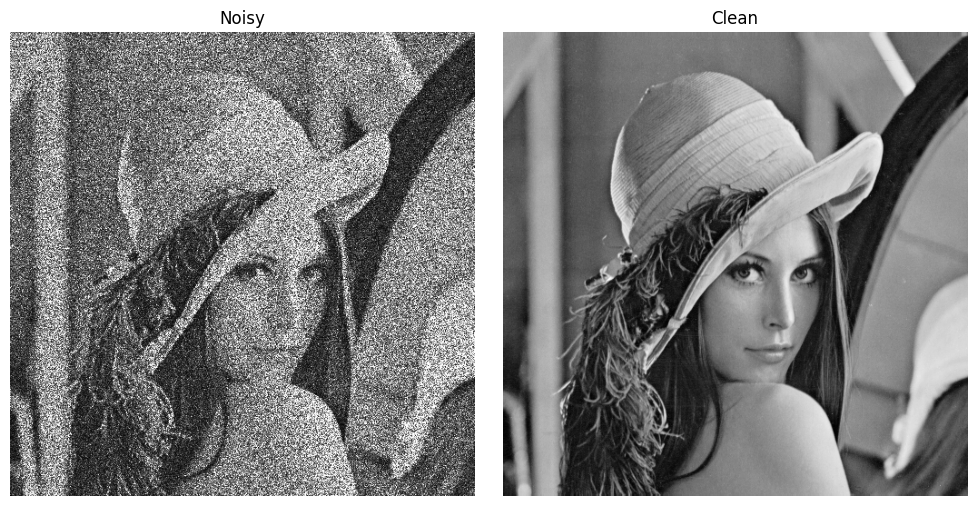

Image shape: (512, 512)
Noisy Image shape: (512, 512)
Image mean: 0.48473498
Noisy Image mean: 0.45580152
Image std: 0.18799537
Noisy Image std: 0.28220677


In [68]:
i = 5
img = data['set12']['clean'][i]
noisy_img = data['set12']['noisy'][i]

# let's visualise the images with cv2, the images are in numpy array format np.float32 between 0 and 1
plt.figure(figsize=(10,5))
# Noisy
plt.subplot(1, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")
# Clean
plt.subplot(1, 2, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.tight_layout()
plt.show()
print("Image shape:", img.shape)
print("Noisy Image shape:", noisy_img.shape)
print("Image mean:", np.mean(img))
print("Noisy Image mean:", np.mean(noisy_img))
print("Image std:", np.std(img))
print("Noisy Image std:", np.std(noisy_img))

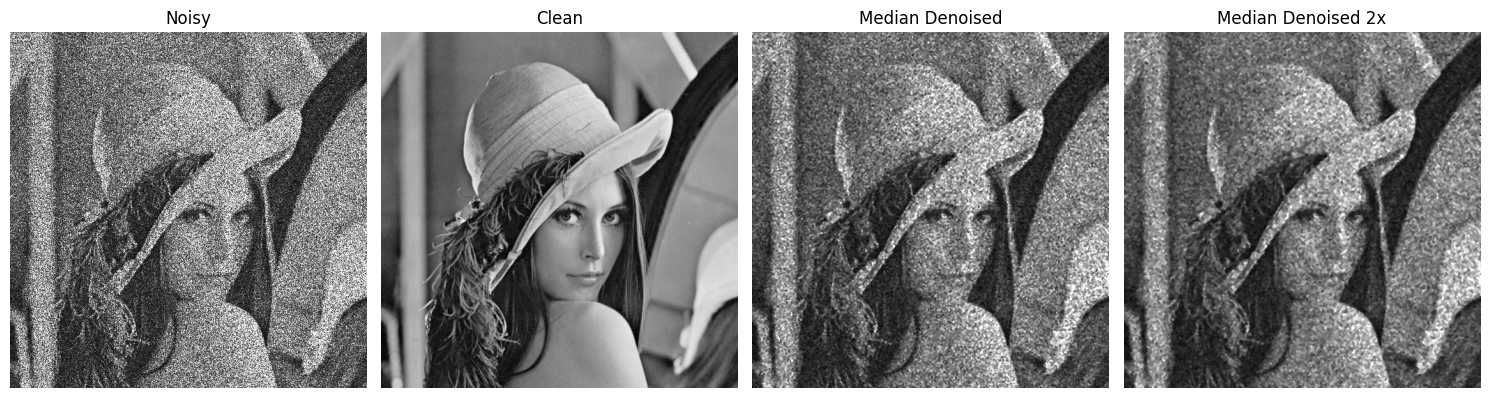

In [69]:
# conversion → uint8
noisy_8 = (noisy_img * 255).astype(np.uint8)

# filtre médian (k=3,5,7…)
k = 3
denoised_8 = cv2.medianBlur(noisy_8, k)
denoised_8_1 = cv2.medianBlur(denoised_8, k)

# retour float32 [0,1]
denoised = denoised_8.astype(np.float32) / 255.0
denoised_1 = denoised_8_1.astype(np.float32) / 255.0


plt.figure(figsize=(15,5))

# Noisy
plt.subplot(1, 4, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

# Original (clean)
plt.subplot(1, 4, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

# Denoised (median)
plt.subplot(1, 4, 3)
plt.imshow(denoised, cmap='gray')
plt.title("Median Denoised")
plt.axis("off")

# Denoised (median, second pass)
plt.subplot(1, 4, 4)
plt.imshow(denoised_1, cmap='gray')
plt.title("Median Denoised 2x")
plt.axis("off")

plt.tight_layout()
plt.show()


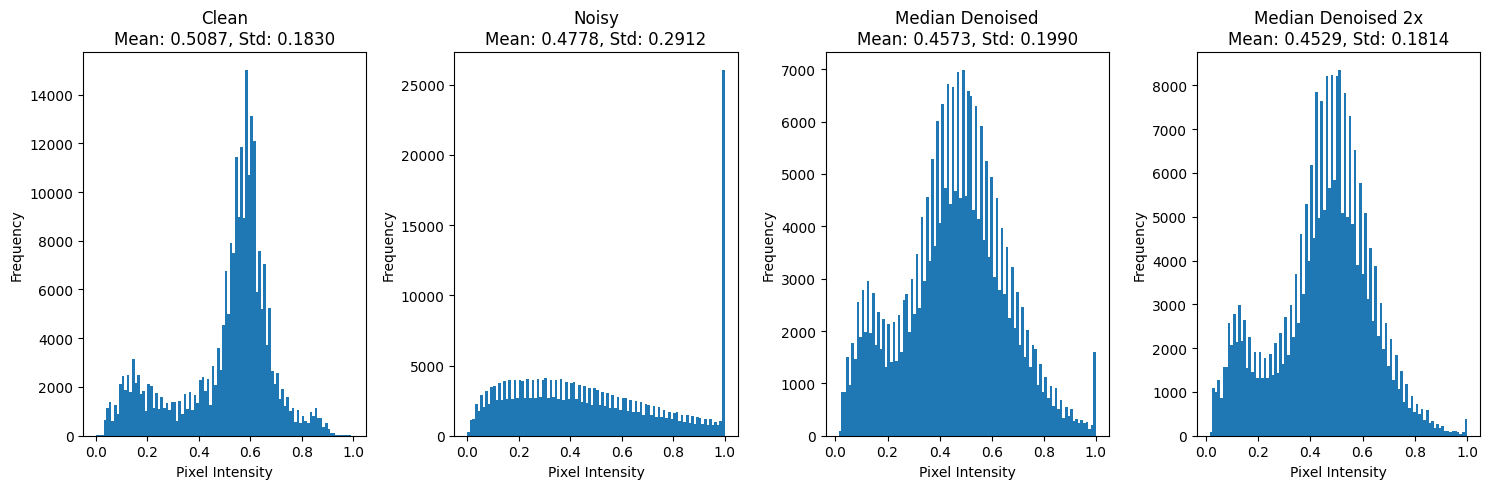

In [58]:
# let's study the mean, std and histogram of original, noisy and denoised images
def plot_image_stats(images, titles):
	plt.figure(figsize=(15,5))
	for i, img in enumerate(images):
		mean = np.mean(img)
		std = np.std(img)
		plt.subplot(1, len(images), i+1)
		plt.hist(img.ravel(), bins=100)
		plt.title(f"{titles[i]}\nMean: {mean:.4f}, Std: {std:.4f}")
		plt.xlabel("Pixel Intensity")
		plt.ylabel("Frequency")
	plt.tight_layout()
	plt.show()
plot_image_stats([img, noisy_img, denoised, denoised_1], ["Clean", "Noisy", "Median Denoised", "Median Denoised 2x"])#!/usr/bin/env python3

In [59]:
len(data['bsd68']['noisy'])

68

In [60]:
data['div2k']['lr4']['DIV2K_train_LR_bicubic']['X4'].keys()

dict_keys(['clean', 'noisy'])

In [61]:
import numpy as np
import cv2
from scipy.ndimage import uniform_filter

images_100 = data['bsd68']['noisy']
images_100 = data['div2k']['lr4']['DIV2K_train_LR_bicubic']['X4']['noisy']

def estimate_noise_var(images, size=7):
    noise_vars = []

    for img in images:
        # moyenne locale
        mean = uniform_filter(img, size)
        mean_sq = uniform_filter(img**2, size)
        var = mean_sq - mean**2     # variance locale image
        noise_vars.append(np.mean(var))  # variance moyenne de l'image

    # variance de bruit globale sur tout le dataset
    return float(np.mean(noise_vars))

images_100 = data['bsd68']['noisy']
images_100 = data['div2k']['lr4']['DIV2K_train_LR_bicubic']['X4']['noisy']
noise_var = estimate_noise_var(images_100, size=7)

print("Estimated noise variance =", noise_var)


Estimated noise variance = 0.05078956112265587


In [65]:
def lee_filter(img, size=7):
    """
    img : float32 entre 0 et 1
    size : taille du voisinage (3,5,7…)
    """
    # moyenne locale
    mean = uniform_filter(img, size)
    # variance locale
    mean_sq = uniform_filter(img**2, size)
    var = mean_sq - mean**2

    # variance du bruit (supposée)
    # noise_var = np.mean(var)
    print("Estimated noise variance =", vN_est)
    # poids
    w = var / (var + vN_est)
    
    # estimation Lee
    img_filtered = mean + w * (img - mean)

    return img_filtered


Estimated noise variance = 0.30715975165367126


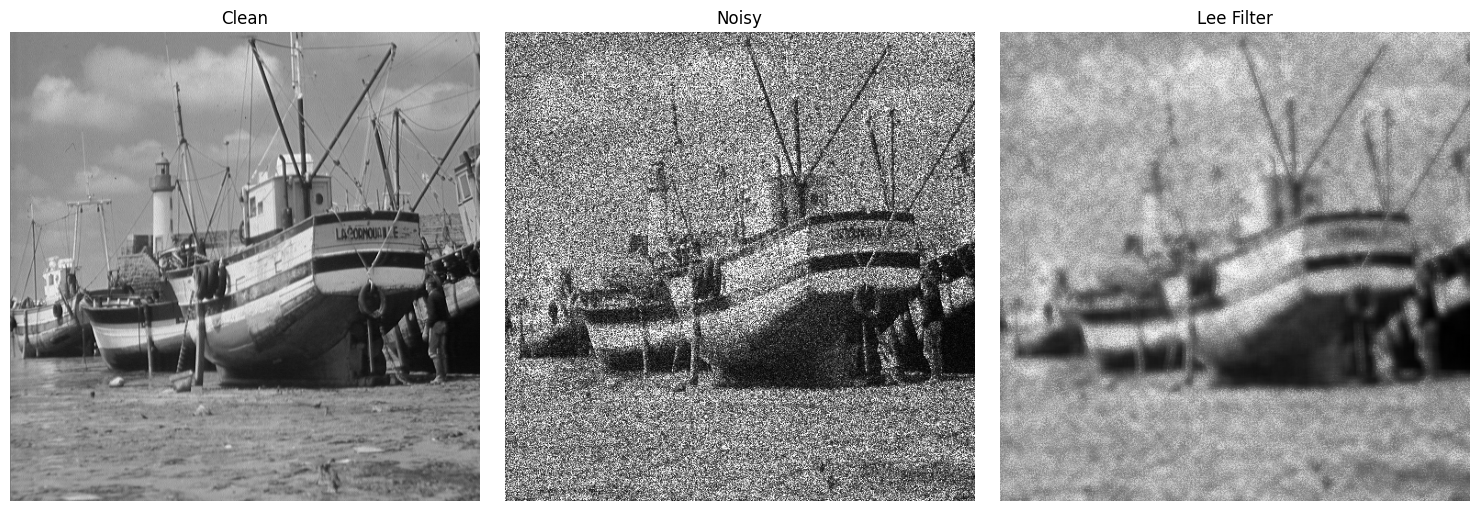

In [66]:
# image float32 [0,1]
lee_img = lee_filter(noisy_img, size=11)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(lee_img, cmap='gray')
plt.title("Lee Filter")
plt.axis("off")

plt.tight_layout()
plt.show()


Estimated noise variance = 0.30715975165367126


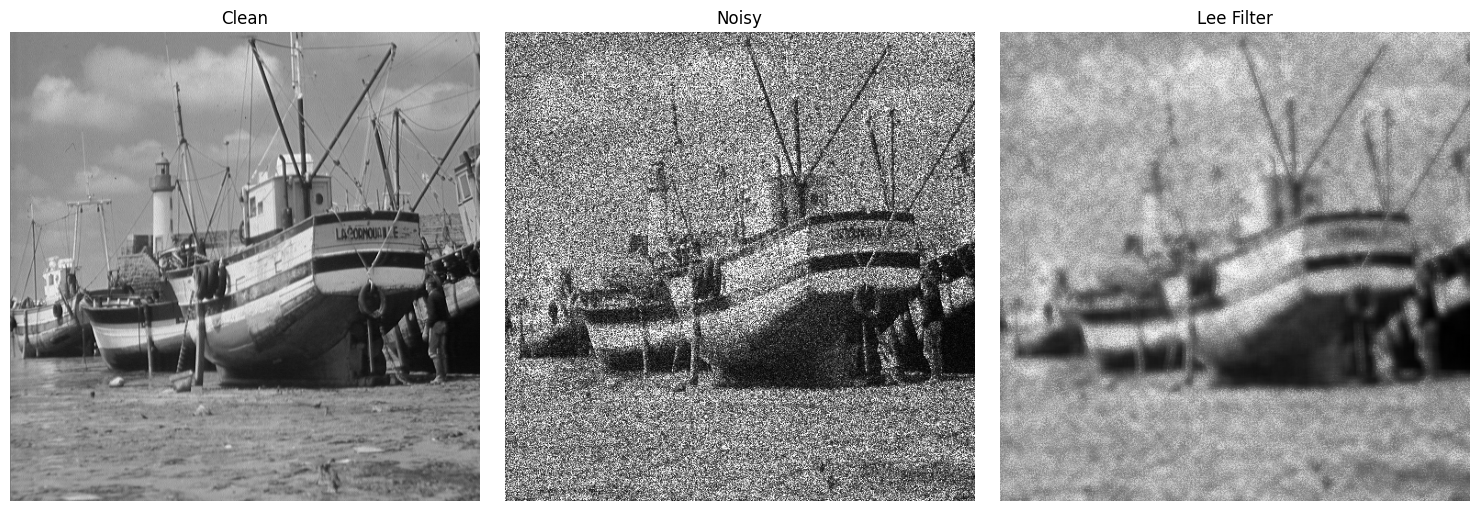

In [67]:
# image float32 [0,1]
lee_img = lee_filter(noisy_img, size=11)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(lee_img, cmap='gray')
plt.title("Lee Filter")
plt.axis("off")

plt.tight_layout()
plt.show()